In [1]:
%matplotlib widget
import numpy as np
import glob
import pandas as pd
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

#[OIII] 5007 --> 6
#Hbeta --> 4
#[NII] 6584 --> 10
#Halpha --> 9
#[SII] 6716 --> 11
#[SII] 6731 --> 13

In [2]:
out_list = glob.glob('*_out.txt')

data_dict = {k:d for k, d in 
    zip([tuple([float(i[1:]) for i in j.split('_')[1:4]]) for j in out_list],
        [pd.read_csv(i, skiprows=2, header=None, 
            sep='\t', index_col=False, names=['line', 'flux']) for i in out_list])}

for i in list(data_dict.values()):
    flux = i['flux']
    i.loc[len(i)] = {'line':'o3_hb', 'flux':(flux.iloc[6] / flux.iloc[4])}
    i.loc[len(i)] = {'line':'n2_ha', 'flux':flux.iloc[10] / flux.iloc[9]}
    i.loc[len(i)] = {'line':'s2_ha', 'flux':(flux.iloc[11] + flux.iloc[13]) / flux.iloc[9]}
    i.loc[len(i)] = {'line':'s2_rat', 'flux':(flux.iloc[11]) / flux.iloc[13]}
    i.loc[len(i)] = {'line':'ha_hb', 'flux':(flux.iloc[11]) / flux.iloc[13]}

Text(0.5, 0, '$T_{\\mathrm{eff}}\\,/\\,\\mathrm{10^3\\,K}$')

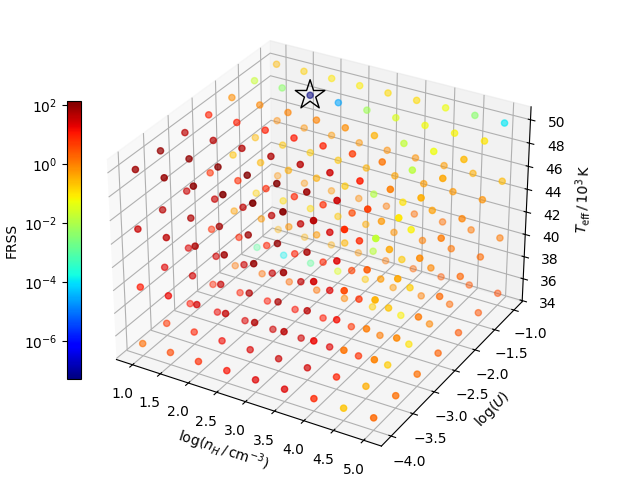

In [3]:
expected = np.array([2.820, 0.190, 0.034, 0.683])
results = {k:sum((expected - v.iloc[-5:-1]['flux'].to_numpy())/expected)**2 for k, v in list(data_dict.items())}
hdens = np.array([i[0] for i in list(results.keys())])
us = np.array([i[1] for i in list(results.keys())])
teffs = np.array([i[2] for i in list(results.keys())])
results_list = np.array(list(results.values()))

min_idx = np.argmin(results_list)
min_coord = (hdens[min_idx], us[min_idx], teffs[min_idx]/1e3)

norm = LogNorm(vmin=min(results_list), vmax=max(results_list))

fig = plt.figure(constrained_layout=True)
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(hdens, us, teffs/1e3, c=results_list, cmap='jet', norm=norm)
ax.scatter(*min_coord, s=500, marker='*', facecolors='none', edgecolor='black')
fig.colorbar(p, fraction=0.025, location='left', pad=0, label='FRSS')

ax.set_xlabel('$\\log(n_H\\,/\\,\\mathrm{cm^{-3}})$')
ax.set_ylabel('$\\log(U)$')
ax.set_zlabel('$T_{\\mathrm{eff}}\\,/\\,\\mathrm{10^3\\,K}$')

Text(0.5, 1.0, '$\\log(U)=-1.5$')

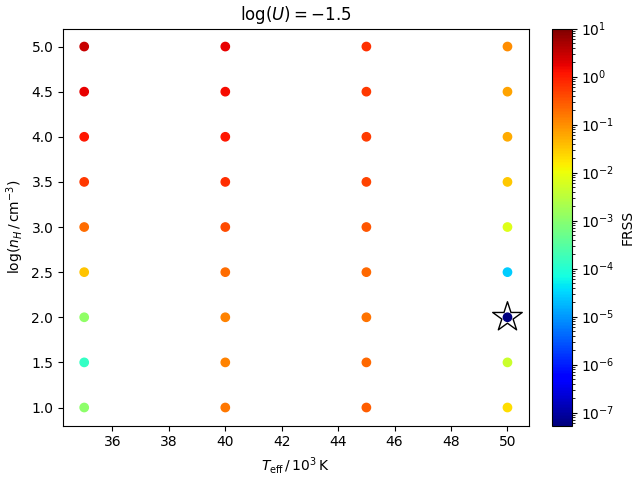

In [4]:
norm2 = LogNorm(vmin=min(results_list), vmax=10)
fig, ax = plt.subplots(constrained_layout=True)
p = ax.scatter(teffs[us == min_coord[1]]/1e3, hdens[us == min_coord[1]], c=results_list[us == min_coord[1]], cmap='jet', norm=norm2)
ax.scatter(min_coord[2], min_coord[0], s=500, marker='*', facecolors='none', edgecolor='black')
fig.colorbar(p, label='FRSS')
ax.set_xlabel('$T_{\\mathrm{eff}}\\,/\\,10^3\\,\\mathrm{K}$')
ax.set_ylabel('$\\log(n_H\\,/\\,\\mathrm{cm^{-3}})$')
ax.set_title('$\\log(U)=-1.5$')

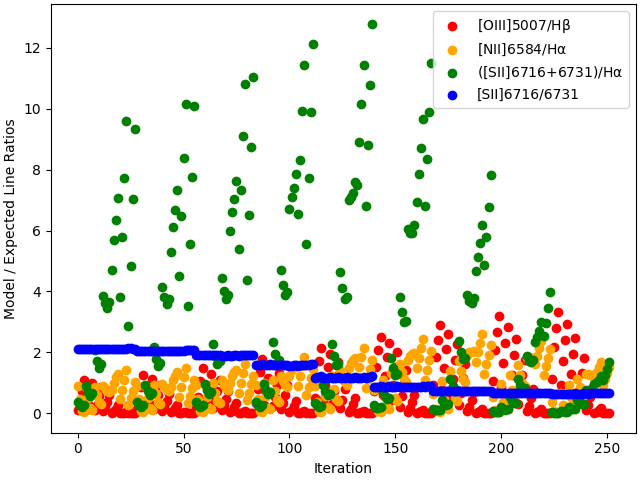

In [5]:
o3_hbs = [i.iloc[14]['flux'] for i in list(data_dict.values())] / expected[0]
n2_has = [i.iloc[15]['flux'] for i in list(data_dict.values())] / expected[1]
s2_has = [i.iloc[16]['flux'] for i in list(data_dict.values())] / expected[2]
s2_rats = [i.iloc[17]['flux'] for i in list(data_dict.values())] / expected[3]
fig, ax = plt.subplots(constrained_layout=True)
ax.scatter(range(len(o3_hbs)), o3_hbs, color='red', 
    label='[OIII]5007/H$\\mathrm{\\beta}$')
ax.scatter(range(len(n2_has)), n2_has, color='orange', 
    label='[NII]6584/H$\\mathrm{\\alpha}$')
ax.scatter(range(len(s2_has)), s2_has, color='green', 
    label='([SII]6716+6731)/H$\\mathrm{\\alpha}$')
ax.scatter(range(len(s2_rats)), s2_rats, color='blue',
    label='[SII]6716/6731')
ax.set_xlabel('Iteration')
ax.set_ylabel('Model / Expected Line Ratios')
ax.legend(loc='best')

In [6]:
min_coord_bdec = (hdens[min_idx], us[min_idx], teffs[min_idx])
best_bdec = data_dict[min_coord_bdec].iloc[18]['flux']
print(f'Best-fit H-density: {min_coord_bdec[0]}')
print(f'Best-fit U: {min_coord_bdec[1]}')
print(f'Best-fit Teff: {min_coord_bdec[2]}')
print(f'Best-fit Balmer Decrement: {best_bdec}')

Best-fit H-density: 2.0
Best-fit U: -1.5
Best-fit Teff: 50000.0
Best-fit Balmer Decrement: 1.3038570417551307
